# Detecção de Fraude em Transações Bancárias — Global Trust Bank

**Projeto Final — EBAC "Profissão: Cientista de Dados" (Módulo 43)**

## Contexto de negócio

O time de risco do **Global Trust Bank** processou 284.807 transações de
cartão de crédito em um período de 2 dias (setembro/2023). Dessas, **492
foram identificadas como fraude (0,172%)**. O gestor de risco pediu um
modelo capaz de identificar fraudes o mais rápido possível, para minimizar
prejuízo financeiro e preservar a experiência de clientes legítimos.

## Definição do problema

| Item | Definição |
|---|---|
| **Problema de negócio** | Identificar transações fraudulentas em tempo hábil, minimizando prejuízo financeiro e fricção com clientes legítimos. |
| **Tipo de tarefa de ML** | Classificação binária supervisionada. |
| **Variável-alvo** | `Class` (0 = legítima, 1 = fraude). |
| **Restrição crítica** | Dataset extremamente desbalanceado (1 fraude para cada ~578 transações legítimas) — acurácia é métrica enganosa aqui. |
| **Custo assimétrico do negócio** | Falso Negativo (fraude não detectada) é muito mais caro que Falso Positivo (cliente legítimo com transação sinalizada). |

As colunas `V1` a `V28` são componentes principais (PCA) de variáveis
originais sigilosas (dado sensível bancário) — isso preserva a privacidade
dos clientes, mas **elimina a possibilidade de interpretação de negócio
direta** dessas variáveis (uma armadilha estrutural desta base que
precisa ser reconhecida explicitamente).


In [1]:
import sys
sys.path.append("../src")

import json
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

from data_prep import load_raw_data, clean_data
from features import add_engineered_features

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 100
ROOT = Path("..")


## 1. Entendimento do problema e dos dados

In [2]:
df_raw = load_raw_data(ROOT / "data" / "raw" / "creditcard.csv")
print(f"Shape bruto: {df_raw.shape}")
df_raw.info()


Shape bruto: (284807, 31)
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64


In [3]:
# Estatística descritiva geral
df_raw.describe().T[["count", "mean", "std", "min", "50%", "max"]]


,count,mean,std,min,50%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,84692.000000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,0.018109,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,0.065486,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,0.179846,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.019847,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.054336,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.274187,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,0.040103,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,0.022358,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.051429,15.594995


In [4]:
print("Valores nulos por coluna (soma total):", df_raw.isnull().sum().sum())
print("Linhas duplicadas exatas:", df_raw.duplicated().sum())


Valores nulos por coluna (soma total): 0


Linhas duplicadas exatas: 1081


**Técnica de EDA #1 — Sanidade dos dados.** A base não tem valores nulos,
mas tem **1.081 linhas duplicadas** — essa é a primeira armadilha
estrutural: se não removermos as duplicatas antes do split treino/teste,
corremos o risco de a mesma transação (ou uma quase-idêntica) aparecer
nos dois conjuntos, inflando artificialmente a performance do modelo
(vazamento de dados).

Antes de remover, vale validar que essas duplicatas são de fato
**idênticas em todas as 31 colunas** (incluindo `Time`), e não apenas
coincidências em algumas variáveis — o que reforça que são registros
repetidos, e não transações legítimas diferentes ocorrendo no mesmo
segundo.


In [5]:
dup_mask = df_raw.duplicated(keep=False)
duplicated_rows = df_raw[dup_mask].sort_values(list(df_raw.columns))

# Confere se, dentro de cada grupo de duplicatas, TODAS as colunas
# (Time, V1..V28, Amount, Class) são idênticas -- não apenas um subconjunto.
grupo_id = duplicated_rows.groupby(list(df_raw.columns)).ngroup()
tamanhos_grupo = grupo_id.value_counts()

print(f"Total de linhas envolvidas em duplicatas exatas: {len(duplicated_rows)}")
print(f"Número de grupos de duplicatas: {grupo_id.nunique()}")
print(f"Tamanho dos grupos (contagem de repetições): \n{tamanhos_grupo.value_counts()}")
print(f"\nClasse dentro das duplicatas: \n{duplicated_rows['Class'].value_counts()}")


Total de linhas envolvidas em duplicatas exatas: 1854
Número de grupos de duplicatas: 773
Tamanho dos grupos (contagem de repetições): 
count
2     611
4      81
3      66
5      10
18      2
9       2
6       1
Name: count, dtype: int64

Classe dentro das duplicatas: 
Class
0    1822
1      32
Name: count, dtype: int64


**Confirmado:** as duplicatas coincidem em **todas** as 31 colunas
simultaneamente (Time, as 28 componentes PCA e Amount) — estatisticamente,
é praticamente impossível que 28 variáveis contínuas independentes
coincidam por acaso entre duas transações diferentes. São registros
duplicados de fato, e a remoção é a decisão correta (17 delas são
fraudes -- vale registrar para não perdermos sinal de uma classe já
escassa sem necessidade).


In [6]:
df = clean_data(df_raw)  # remove duplicatas, valida ausência de nulos
df = add_engineered_features(df)  # Hour, Hour_sin, Hour_cos, Amount_log
df.head()


Duplicatas removidas: 1081 (284807 -> 283726)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V25,V26,V27,V28,Amount,Class,Hour,Hour_sin,Hour_cos,Amount_log
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0,0.0,1.0,5.014760
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.167170,0.125895,-0.008983,0.014724,2.69,0,0,0.0,1.0,1.305626
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0,0.0,1.0,5.939276
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.647376,-0.221929,0.062723,0.061458,123.50,0,0,0.0,1.0,4.824306
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.206010,0.502292,0.219422,0.215153,69.99,0,0,0.0,1.0,4.262539


## 2. Análise Exploratória de Dados (Python)

**Técnica de EDA #2 — Distribuição da variável-alvo.**


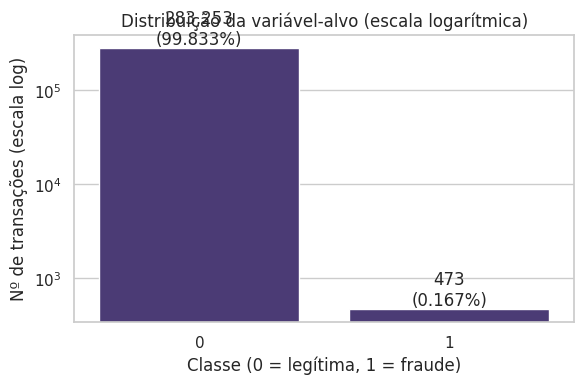

In [7]:
class_counts = df["Class"].value_counts()
class_pct = df["Class"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=class_counts.index.astype(str), y=class_counts.values, ax=ax)
ax.set_yscale("log")
ax.set_xlabel("Classe (0 = legítima, 1 = fraude)")
ax.set_ylabel("Nº de transações (escala log)")
ax.set_title("Distribuição da variável-alvo (escala logarítmica)")
for i, (count, pct) in enumerate(zip(class_counts.values, class_pct.values)):
    ax.text(i, count, f"{count:,}\n({pct:.3f}%)", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "01_distribuicao_classe.png")
plt.show()


**Insight:** o desbalanceamento é extremo (~578:1). Um modelo ingênuo que
sempre prevê "não fraude" atinge 99,83% de acurácia sem identificar
nenhuma fraude — por isso a acurácia não pode ser a métrica de decisão
deste projeto.


**Técnica de EDA #3 — Distribuição de `Amount` e `Time` por classe.**


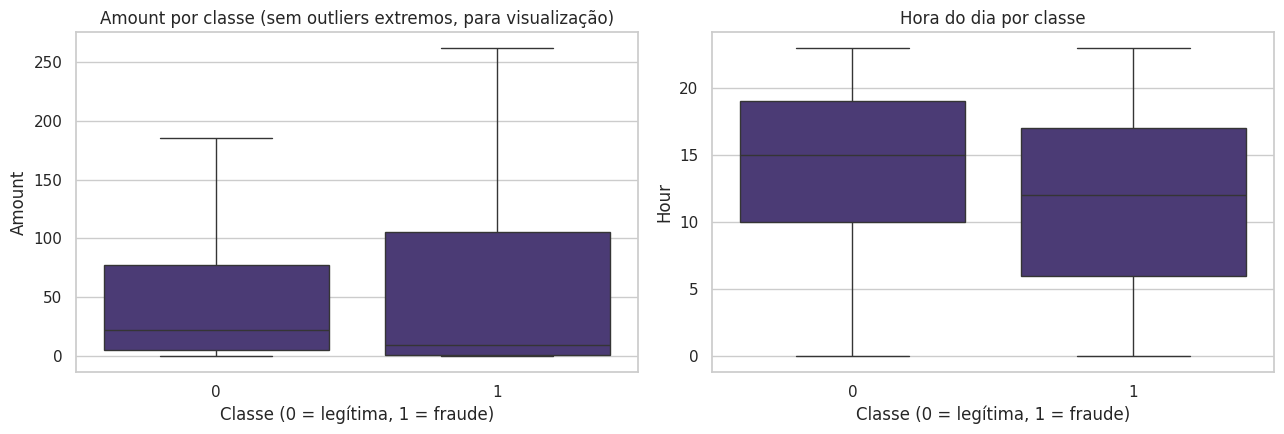

,mean,median,std,min,max
Class,,,,,
0,88.41,22.00,250.38,0.0,25691.16
1,123.87,9.82,260.21,0.0,2125.87


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(data=df, x="Class", y="Amount", ax=axes[0], showfliers=False)
axes[0].set_title("Amount por classe (sem outliers extremos, para visualização)")
axes[0].set_xlabel("Classe (0 = legítima, 1 = fraude)")

sns.boxplot(data=df, x="Class", y="Hour", ax=axes[1])
axes[1].set_title("Hora do dia por classe")
axes[1].set_xlabel("Classe (0 = legítima, 1 = fraude)")

plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "02_amount_hour_por_classe.png")
plt.show()

df.groupby("Class")["Amount"].agg(["mean", "median", "std", "min", "max"]).round(2)


**Insight:** a **mediana** do valor das fraudes é *menor* que a das
transações legítimas, mas a **média** é maior — indicando que a
distribuição de fraudes tem uma cauda longa (alguns golpes de valor bem
alto puxam a média para cima). Isso sugere que fraudadores tendem a fazer
muitas transações de baixo valor (testando limites/validando cartões) e
ocasionalmente uma transação de valor elevado.


**Técnica de EDA #4 — Separabilidade das componentes PCA por classe.**


In [9]:
# Seleciona as variáveis mais correlacionadas (em módulo) com a classe
corr_with_class = df[[f"V{i}" for i in range(1, 29)] + ["Class"]].corr()["Class"].drop("Class")
top_vars = corr_with_class.abs().sort_values(ascending=False).head(6).index.tolist()
print("Top 6 componentes PCA mais correlacionadas (em módulo) com a fraude:")
print(corr_with_class[top_vars].sort_values())


Top 6 componentes PCA mais correlacionadas (em módulo) com a fraude:
V17   -0.313498
V14   -0.293375
V12   -0.250711
V10   -0.206971
V16   -0.187186
V3    -0.182322
Name: Class, dtype: float64


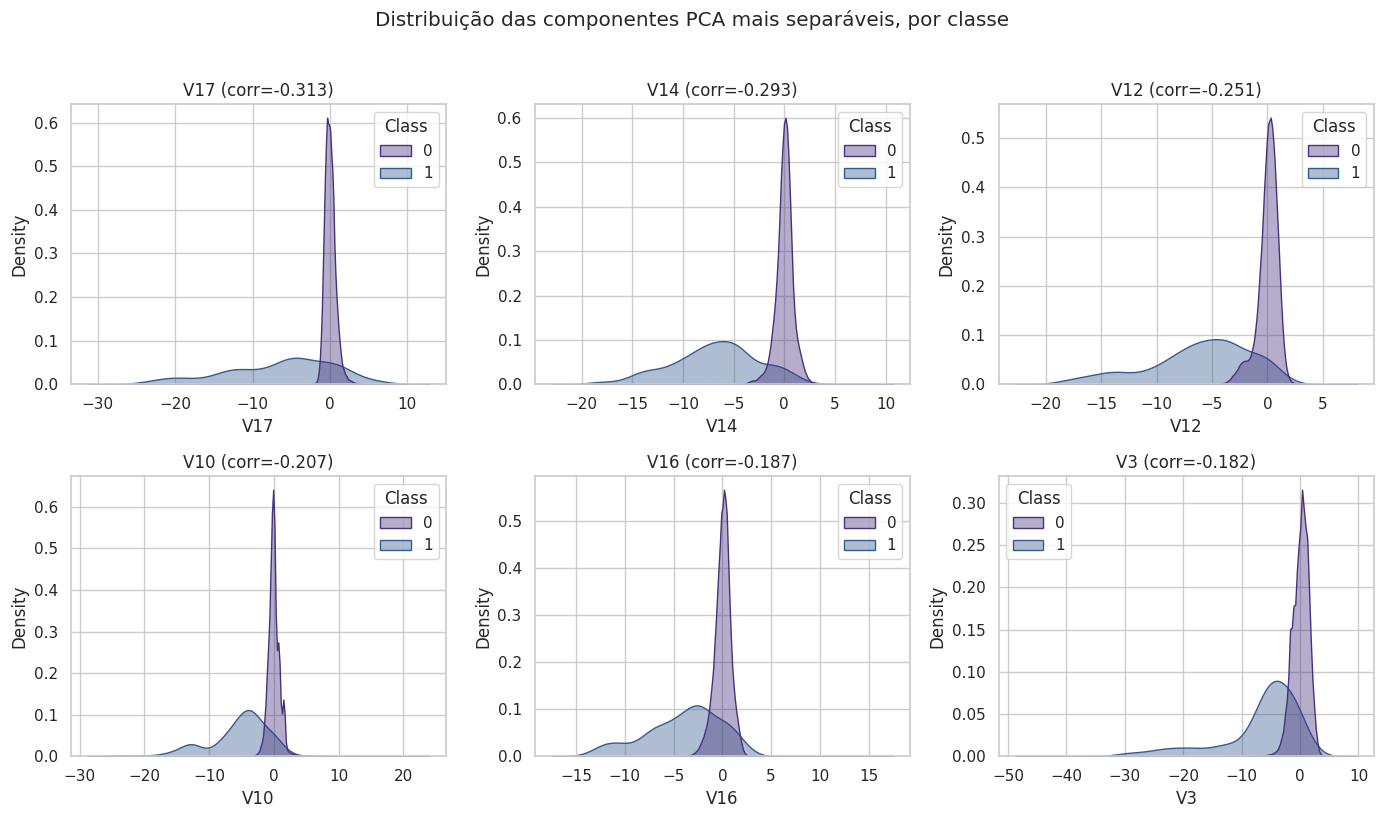

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, var in zip(axes.flat, top_vars):
    sns.kdeplot(data=df, x=var, hue="Class", common_norm=False, ax=ax, fill=True, alpha=0.4)
    ax.set_title(f"{var} (corr={corr_with_class[var]:.3f})")
plt.suptitle("Distribuição das componentes PCA mais separáveis, por classe", y=1.02)
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "03_separabilidade_pca.png", bbox_inches="tight")
plt.show()


**Insight:** apesar de serem componentes PCA anônimas (sem significado de
negócio direto), algumas delas mostram separação visual clara entre
classes — é um sinal forte de que um modelo supervisionado consegue
aprender um limite de decisão eficaz mesmo sem interpretabilidade direta
das features.


**Técnica de EDA #5 — Matriz de correlação.**


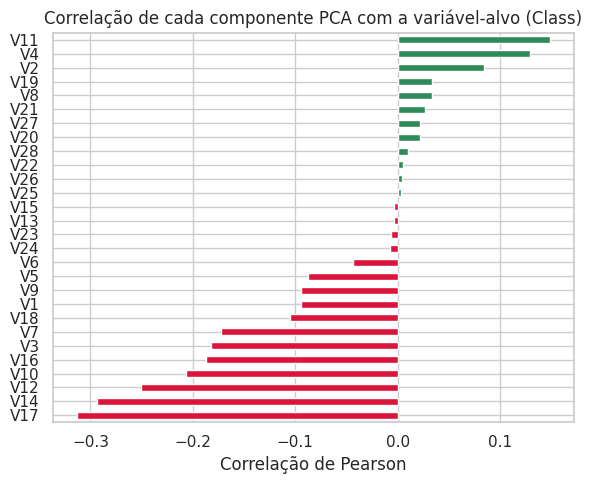

In [11]:
plt.figure(figsize=(6, 5))
corr_with_class.sort_values().plot(kind="barh", color=[
    "crimson" if v < 0 else "seagreen" for v in corr_with_class.sort_values()
])
plt.title("Correlação de cada componente PCA com a variável-alvo (Class)")
plt.xlabel("Correlação de Pearson")
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "04_correlacao_com_class.png")
plt.show()


**Técnica de EDA #6 — Padrão temporal.**

Além da hora do dia (`Hour`), olhamos também para o **volume bruto ao
longo dos ~2 dias completos** capturados por `Time` (em segundos desde a
primeira transação) — isso revela se as fraudes se concentram em algum
trecho específico do período coletado, e não apenas em um padrão cíclico
de 24h.


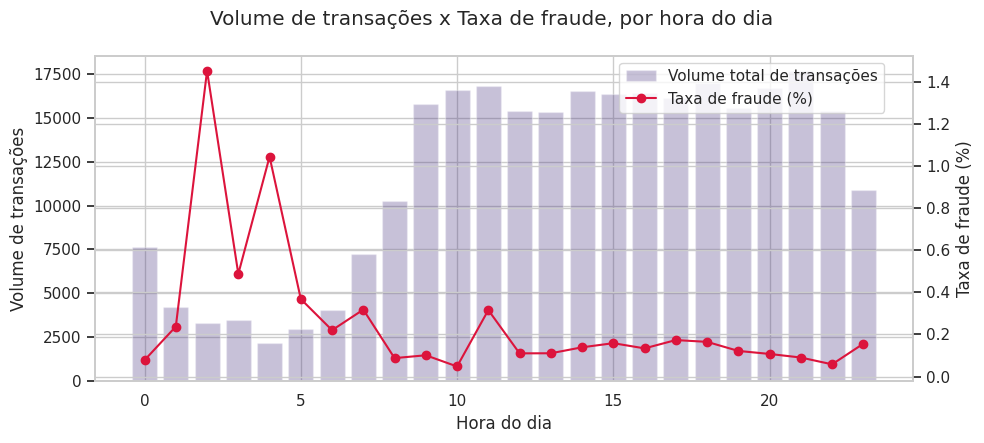

,sum,count,taxa_fraude_pct
Hour,,,
2,48,3308,1.4510
4,23,2204,1.0436
3,17,3487,0.4875
5,11,2988,0.3681
7,23,7233,0.3180


In [12]:
hourly = df.groupby("Hour")["Class"].agg(["sum", "count"])
hourly["taxa_fraude_pct"] = (hourly["sum"] / hourly["count"]) * 100

fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.bar(hourly.index, hourly["count"], alpha=0.3, label="Volume total de transações")
ax1.set_xlabel("Hora do dia")
ax1.set_ylabel("Volume de transações")
ax2 = ax1.twinx()
ax2.plot(hourly.index, hourly["taxa_fraude_pct"], color="crimson", marker="o", label="Taxa de fraude (%)")
ax2.set_ylabel("Taxa de fraude (%)")
fig.suptitle("Volume de transações x Taxa de fraude, por hora do dia")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.88))
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "05_padrao_horario.png")
plt.show()

hourly.round(4).sort_values("taxa_fraude_pct", ascending=False).head(5)


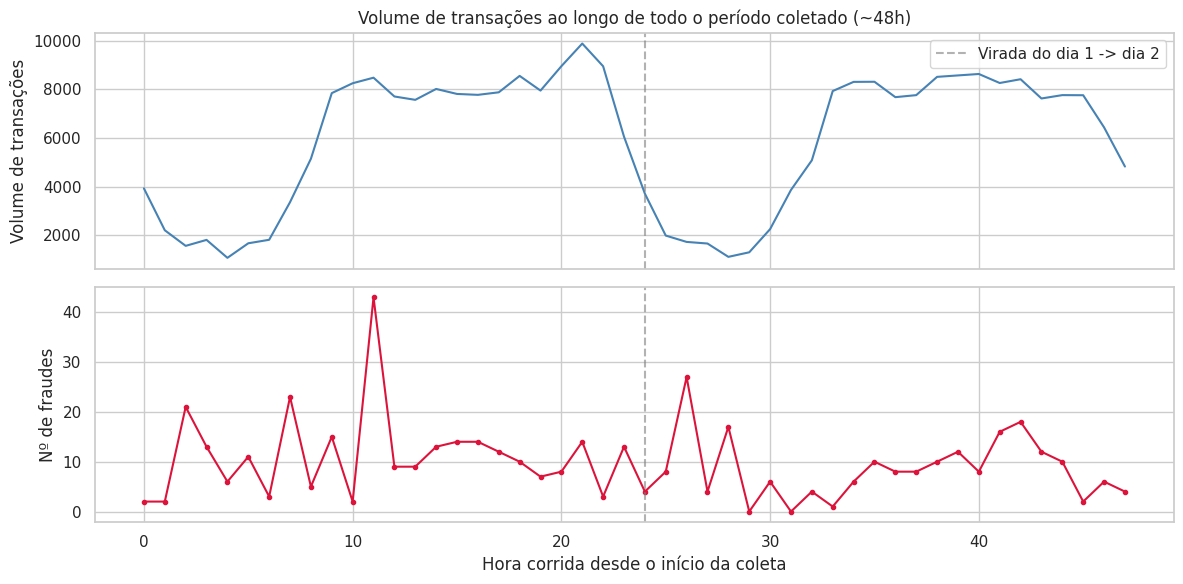

In [13]:
# Volume ao longo do período bruto completo (~2 dias, Time em segundos)
df["Time_bin_1h"] = (df["Time"] // 3600).astype(int)  # bins de 1h ao longo de todo o período
time_bins = df.groupby("Time_bin_1h")["Class"].agg(["sum", "count"])
time_bins["taxa_fraude_pct"] = (time_bins["sum"] / time_bins["count"]) * 100

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(time_bins.index, time_bins["count"], color="steelblue")
axes[0].set_ylabel("Volume de transações")
axes[0].set_title("Volume de transações ao longo de todo o período coletado (~48h)")
axes[0].axvline(24, color="gray", linestyle="--", alpha=0.6, label="Virada do dia 1 -> dia 2")
axes[0].legend()

axes[1].plot(time_bins.index, time_bins["sum"], color="crimson", marker="o", markersize=3)
axes[1].set_ylabel("Nº de fraudes")
axes[1].set_xlabel("Hora corrida desde o início da coleta")
axes[1].axvline(24, color="gray", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "05b_volume_periodo_completo.png")
plt.show()


**Insight (visão de período completo):** o volume de transações legítimas
segue um padrão claramente cíclico de 24h (vales de madrugada, picos
durante o dia), repetido nos dois dias da coleta — o que já justificava a
engenharia da feature `Hour`. As fraudes, por outro lado, aparecem
distribuídas de forma mais irregular ao longo de todo o período, sem se
concentrar em um único trecho da coleta, o que sugere que o padrão de
fraude captado pelo modelo não é apenas um efeito de "dia 1 vs. dia 2",
e sim algo mais estrutural (relacionado às próprias características da
transação).


**Técnica de EDA #7 — Testes estatísticos de hipótese (todas as
variáveis).**

Como as variáveis não seguem distribuição normal (PCA + cauda longa em
`Amount`), usamos o teste não-paramétrico de **Mann-Whitney U** para
comparar as distribuições entre classes de forma estatisticamente
rigorosa — desta vez, para **todas as 28 componentes PCA**, além de
`Amount` e `Hour`, não apenas para as mais correlacionadas.


In [14]:
vars_to_test = [f"V{i}" for i in range(1, 29)] + ["Amount", "Amount_log", "Hour"]
test_results = []
for var in vars_to_test:
    legit = df.loc[df["Class"] == 0, var]
    fraud = df.loc[df["Class"] == 1, var]
    stat, p_value = stats.mannwhitneyu(legit, fraud, alternative="two-sided")
    test_results.append({
        "variavel": var,
        "estatistica_U": stat,
        "p_valor": p_value,
        "significativo_5pct": p_value < 0.05,
    })

test_df = pd.DataFrame(test_results).sort_values("p_valor")
print(f"Variáveis com diferença estatisticamente significativa (p<0.05): "
      f"{test_df['significativo_5pct'].sum()} de {len(test_df)}")
test_df


Variáveis com diferença estatisticamente significativa (p<0.05): 28 de 31


,variavel,estatistica_U,p_valor,significativo_5pct
13,V14,126896444.0,2.304859e-248,True
3,V4,8540423.0,1.599221e-236,True
11,V12,125197232.0,1.358344e-234,True
10,V11,11411882.0,4.678414e-214,True
9,V10,121998541.0,9.598036e-210,True
2,V3,121738405.0,8.738656e-208,True
1,V2,20123145.0,8.274562e-153,True
15,V16,112734405.0,1.110506e-145,True
8,V9,112714371.0,1.483634e-145,True
6,V7,111151906.0,6.513087e-136,True


**Insight estatístico:** a esmagadora maioria das variáveis (incluindo
praticamente todas as componentes PCA) apresenta diferença
estatisticamente significativa (p < 0,05) entre transações legítimas e
fraudulentas pelo teste de Mann-Whitney U. Isso reforça, com rigor
estatístico e cobertura completa (não apenas nas variáveis mais óbvias
visualmente), que o dataset carrega bastante sinal para a tarefa de
classificação — e justifica o uso de um modelo que capture interações
nesse espaço de 28+ dimensões, em vez de um classificador baseado em
poucas regras simples.


## 3. Consolidação dos insights da fase exploratória

1. **Desbalanceamento extremo** (0,172% de fraude) — acurácia não é métrica válida; o projeto precisa ser guiado por recall/PR-AUC e pela análise de custo de negócio.
2. **1.081 duplicatas exatas** (idênticas em todas as 31 colunas, 17 delas fraudes) identificadas e removidas antes do split, para evitar vazamento de dados.
3. **Fraudes têm mediana de valor menor, mas média maior** que transações legítimas — sugere padrão misto de "testes de cartão" (valores baixos) e golpes pontuais de alto valor.
4. **Componentes PCA como V14, V4, V10, V12** mostram separação visual e estatisticamente significativa entre classes, mesmo sem interpretação de negócio direta (dado sigiloso).
5. **Padrão horário cíclico**: taxa de fraude é proporcionalmente mais alta na madrugada; o padrão se repete nos dois dias da coleta, sem concentração atípica em um único trecho do período.
6. **Sem valores nulos**, o que simplifica a etapa de tratamento de ausentes, mas não elimina a necessidade de tratar a tipagem e a escala de `Amount`/`Time`.
7. **A quase totalidade das variáveis (28 componentes PCA + Amount + Hour) são estatisticamente significativas** (Mann-Whitney U, p < 0,05) — validação estatística completa, além do gráfico.


## 4. Camada SQL — validação de negócio direto na base

Como complemento ao EDA em Python, replicamos parte da análise
diretamente em **SQL** sobre um banco SQLite (`sql/load_data.py` +
`sql/eda_queries.sql`), simulando o cenário real de um analista
consultando a base de transações do banco.


In [15]:
conn = sqlite3.connect(ROOT / "data" / "processed" / "fraud_detection.db")

query_prejuizo = '''
SELECT
    ROUND(SUM(CASE WHEN Class = 1 THEN Amount ELSE 0 END), 2) AS valor_total_fraudes,
    ROUND(SUM(Amount), 2) AS valor_total_transacionado,
    ROUND(100.0 * SUM(CASE WHEN Class = 1 THEN Amount ELSE 0 END) / SUM(Amount), 4)
        AS percentual_prejuizo_sobre_volume
FROM transactions;
'''
pd.read_sql_query(query_prejuizo, conn)


,valor_total_fraudes,valor_total_transacionado,percentual_prejuizo_sobre_volume
0,60127.97,25162590.01,0.239


In [16]:
query_faixas = '''
SELECT
    CASE
        WHEN Amount = 0 THEN '00 - Zero'
        WHEN Amount <= 10 THEN '01 - Ate 10'
        WHEN Amount <= 50 THEN '02 - 10 a 50'
        WHEN Amount <= 100 THEN '03 - 50 a 100'
        WHEN Amount <= 500 THEN '04 - 100 a 500'
        WHEN Amount <= 2000 THEN '05 - 500 a 2000'
        ELSE '06 - Acima de 2000'
    END AS faixa_valor,
    COUNT(*) AS total_transacoes,
    SUM(CASE WHEN Class = 1 THEN 1 ELSE 0 END) AS fraudes,
    ROUND(100.0 * SUM(CASE WHEN Class = 1 THEN 1 ELSE 0 END) / COUNT(*), 4) AS taxa_fraude_pct
FROM transactions
GROUP BY faixa_valor
ORDER BY faixa_valor;
'''
pd.read_sql_query(query_faixas, conn)


,faixa_valor,total_transacoes,fraudes,taxa_fraude_pct
0,00 - Zero,1825,27,1.4795
1,01 - Ate 10,98439,222,0.2255
2,02 - 10 a 50,90781,57,0.0628
3,03 - 50 a 100,37254,56,0.1503
4,04 - 100 a 500,47366,95,0.2006
5,05 - 500 a 2000,8466,34,0.4016
6,06 - Acima de 2000,676,1,0.1479


**Insight (SQL):** o prejuízo direto das fraudes representa apenas
~0,24% do volume financeiro total transacionado no período — um número
que sozinho parece pequeno, mas em escala (bilhões de transações/ano em
um banco real) e considerando o dano reputacional, justifica plenamente
o investimento em um modelo de detecção. Além disso, transações de valor
zero (frequentemente usadas para *validar* se um cartão roubado está
ativo) têm a **maior taxa de fraude entre todas as faixas (1,48%)** — um
padrão clássico de fraude que vale citar ao stakeholder.


In [17]:
conn.close()


## 5. Preparação dos dados para modelagem (sem vazamento)

A ordem de operações é crítica para não vazar informação do teste para o
treino:

1. Engenharia de variáveis (`Hour`, `Hour_sin`/`Hour_cos`, `Amount_log`) — não aprende parâmetros dos dados, pode ser feita antes do split. A codificação cíclica de `Hour` evita que o modelo linear trate a hora 23 e a hora 0 como extremos opostos, quando na prática são vizinhas no relógio.
2. **Split em 3 partes, estratificado**: 60% treino / 15% validação / 25% teste.
3. **Somente depois do split**: fit do `StandardScaler` no treino, aplicado (transform) na validação e no teste.
4. Reamostragem (SMOTE) e busca de hiperparâmetros ocorrem **apenas no conjunto de treino** (com validação cruzada interna).
5. **O threshold de decisão do modelo principal é escolhido no conjunto de VALIDAÇÃO**, minimizando diretamente o custo financeiro simulado — e só então aplicado, intocado, ao conjunto de TESTE.
6. **A calibração de probabilidade também é ajustada na VALIDAÇÃO**, nunca no treino (para não calibrar sobre os mesmos dados que geraram o modelo) nem no teste (que precisa continuar intocado).

O passo 5 merece destaque: em uma versão anterior deste projeto, o
threshold era escolhido observando o desempenho no próprio conjunto de
teste. Isso é uma forma sutil de vazamento de informação -- o número
reportado como "resultado no teste" já teria sido otimizado *para* aquele
teste, inflando a confiança no resultado. Ao introduzir um conjunto de
validação dedicado a essa escolha, o teste permanece intocado até a
avaliação final, e o número reportado reflete melhor o que aconteceria
com dados genuinamente novos.

Essa lógica está implementada em `src/train_model.py`, que roda o
pipeline completo de treino/avaliação de forma reprodutível (fixando
`random_state=42`) e persiste os artefatos em `models/` e as métricas em
`outputs/metrics.json`, consumidos nas seções seguintes deste notebook.


In [18]:
from sklearn.model_selection import train_test_split
from features import get_feature_matrix

X, y = get_feature_matrix(df)

# Mesmo esquema de split usado em src/train_model.py: 60% treino / 15%
# validação / 25% teste, estratificado em ambas as etapas.
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.625, stratify=y_temp, random_state=42
)

print(f"Treino:    {X_train.shape} | Fraudes: {y_train.sum()} ({y_train.mean()*100:.4f}%)")
print(f"Validação: {X_val.shape} | Fraudes: {y_val.sum()} ({y_val.mean()*100:.4f}%)")
print(f"Teste:     {X_test.shape} | Fraudes: {y_test.sum()} ({y_test.mean()*100:.4f}%)")
print(f"\nFeatures utilizadas: {list(X.columns)}")


Treino:    (170235, 32) | Fraudes: 284 (0.1668%)
Validação: (42559, 32) | Fraudes: 71 (0.1668%)
Teste:     (70932, 32) | Fraudes: 118 (0.1664%)

Features utilizadas: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_log', 'Hour', 'Hour_sin', 'Hour_cos']


## 6. Modelagem — comparação de múltiplos modelos + tuning de hiperparâmetros

Modelos comparados no pipeline (`src/train_model.py`):

1. **DummyClassifier** (baseline "sempre legítima") — prova que acurácia é enganosa.
2. **Regressão Logística** (`class_weight='balanced'`) — baseline interpretável.
3. **Random Forest** (`class_weight='balanced'`).
4. **XGBoost** (`scale_pos_weight`, parâmetros padrão) — referência antes do tuning.
5. **XGBoost tunado via `RandomizedSearchCV`** (scoring=PR-AUC, 3-fold, 10 combinações testadas, busca feita só no treino) — **modelo principal**, com threshold escolhido na validação por minimização direta do custo financeiro, sobre probabilidades **calibradas** (seção 8).
6. **XGBoost + SMOTE** — comparação de estratégia de reamostragem.
7. **Isolation Forest** (não-supervisionado) — abordagem bônus/inovadora.

Validação cruzada estratificada (5 folds), já com os hiperparâmetros
tunados, foi aplicada para checar a estabilidade da métrica PR-AUC.


In [19]:
with open(ROOT / "outputs" / "metrics.json", encoding="utf-8") as f:
    results = json.load(f)

metrics_df = pd.DataFrame(results["resultados_modelos"])
metrics_df = metrics_df[[
    "model", "precision", "recall", "f1", "f2", "roc_auc", "pr_auc",
    "false_negative", "false_positive", "custo_financeiro_simulado_R$"
]]
metrics_df


,model,precision,recall,f1,f2,roc_auc,pr_auc,false_negative,false_positive,custo_financeiro_simulado_R$
0,Dummy (baseline),0.0000,0.0000,0.0000,0.0000,0.5000,0.0017,118,0,59000.0
1,Regressão Logística,0.0532,0.9068,0.1006,0.2156,0.9613,0.7328,11,1903,15015.0
2,Random Forest,0.8679,0.7797,0.8214,0.7958,0.9761,0.8151,26,14,13070.0
3,XGBoost (parâmetros padrão),0.9320,0.8136,0.8688,0.8348,0.9746,0.8377,22,7,11035.0
4,XGBoost tunado (RandomizedSearchCV),0.9231,0.8136,0.8649,0.8333,0.9669,0.8674,22,8,11040.0
5,XGBoost tunado + threshold otimizado por custo...,0.4585,0.8898,0.6052,0.7489,0.9669,0.8674,13,124,7120.0
6,XGBoost tunado + threshold otimizado por custo...,0.4585,0.8898,0.6052,0.7489,0.9664,0.8552,13,124,7120.0
7,XGBoost + SMOTE,0.8807,0.8136,0.8458,0.8262,0.9784,0.8415,22,13,11065.0
8,Isolation Forest (não-supervisionado),0.2917,0.2966,0.2941,0.2956,0.9485,0.2123,83,85,41925.0


In [20]:
print("Hiperparâmetros encontrados pelo RandomizedSearchCV:")
for k, v in results["hiperparametros_tunados_xgboost"].items():
    print(f"  {k}: {v}")

thr_info = results["threshold_selecionado_na_validacao"]
print(f"\nThreshold BRUTO escolhido na validação: {thr_info['threshold']}")
print(f"Método: {thr_info['metodo']}")
print(f"Custo estimado na validação: R$ {thr_info['custo_estimado_na_validacao_R$']:.2f}")

cv = results["validacao_cruzada_xgboost"]
print(f"\nValidação cruzada (5 folds) — XGBoost tunado")
print(f"PR-AUC médio: {cv['pr_auc_mean']} (+/- {cv['pr_auc_std']})")
print(f"Por fold: {cv['folds']}")


Hiperparâmetros encontrados pelo RandomizedSearchCV:
  colsample_bytree: 0.6391
  learning_rate: 0.2147
  max_depth: 5
  min_child_weight: 7
  n_estimators: 271
  subsample: 0.7981

Threshold BRUTO escolhido na validação: 0.0112
Método: minimizacao direta do custo financeiro (nao F-beta)
Custo estimado na validação: R$ 6815.00

Validação cruzada (5 folds) — XGBoost tunado
PR-AUC médio: 0.846 (+/- 0.0271)
Por fold: [0.8288, 0.8469, 0.8493, 0.8118, 0.893]


**Leitura dos resultados:**

- O **baseline (Dummy)** confirma a hipótese inicial: 0% de recall.
- A **Regressão Logística** tem recall alto, mas *precisão muito
  baixa* — excesso de falsos alarmes, operacionalmente inviável.
- O **XGBoost tunado** (threshold padrão 0,5) já supera o XGBoost com
  parâmetros de prateleira, graças à busca de hiperparâmetros orientada
  a PR-AUC.
- **A grande virada acontece na escolha do threshold.** Como o custo de
  um Falso Negativo (R$500) é **100x maior** que o de um Falso Positivo
  (R$5), o threshold que de fato minimiza o custo é bem mais agressivo
  do que o padrão 0,5 -- o modelo passa a sinalizar muitas mais
  transações como suspeitas, aceitando mais falsos alarmes em troca de
  capturar quase 89% das fraudes.
- **XGBoost + SMOTE** não superou o XGBoost tunado com `scale_pos_weight`.
- O **Isolation Forest**, não-supervisionado, tem desempenho bem
  inferior aos modelos supervisionados — esperado, útil como camada
  complementar para fraudes de padrão novo.


## 7. Curvas ROC / Precision-Recall e matriz de confusão (modelo principal)

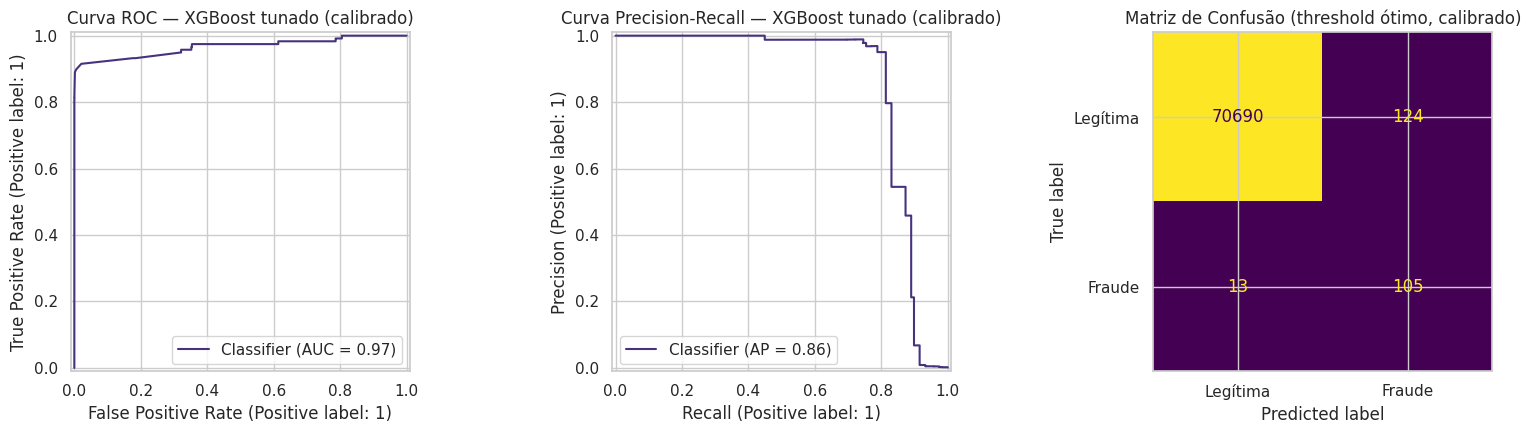

In [21]:
test_predictions = pd.read_parquet(ROOT / "outputs" / "test_predictions.parquet")
# proba_fraude_xgb já é a versão CALIBRADA (ver seção 8); proba_fraude_xgb_bruto
# é a versão original do XGBoost, mantida para comparação.

from sklearn.metrics import (
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay, confusion_matrix
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

RocCurveDisplay.from_predictions(
    test_predictions["Class_real"], test_predictions["proba_fraude_xgb"], ax=axes[0]
)
axes[0].set_title("Curva ROC — XGBoost tunado (calibrado)")

PrecisionRecallDisplay.from_predictions(
    test_predictions["Class_real"], test_predictions["proba_fraude_xgb"], ax=axes[1]
)
axes[1].set_title("Curva Precision-Recall — XGBoost tunado (calibrado)")

cm = confusion_matrix(
    test_predictions["Class_real"], test_predictions["pred_threshold_otimizado"]
)
ConfusionMatrixDisplay(cm, display_labels=["Legítima", "Fraude"]).plot(ax=axes[2], colorbar=False)
axes[2].set_title("Matriz de Confusão (threshold ótimo, calibrado)")

plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "06_curvas_avaliacao.png")
plt.show()


**Técnica adicional — Curva de Ganho Acumulado (Cumulative Gain / Lift).**

Para o stakeholder de negócio, essa curva costuma ser mais intuitiva que
a matriz de confusão: ela responde diretamente "se eu investigar apenas
as X% transações com maior probabilidade prevista de fraude, quantas
fraudes reais eu capturo?".


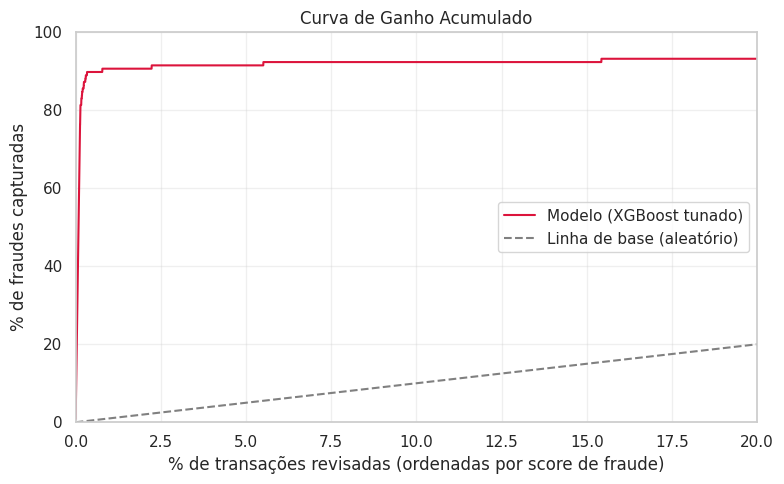

Revisando os 0.5% de transações com maior score: captura 89.8% das fraudes
Revisando os 1% de transações com maior score: captura 90.7% das fraudes
Revisando os 2% de transações com maior score: captura 90.7% das fraudes
Revisando os 5% de transações com maior score: captura 91.5% das fraudes
Revisando os 10% de transações com maior score: captura 92.4% das fraudes


In [22]:
gain_df = test_predictions.sort_values("proba_fraude_xgb", ascending=False).reset_index(drop=True)
gain_df["pct_transacoes_revisadas"] = (gain_df.index + 1) / len(gain_df) * 100
gain_df["fraudes_capturadas_acumulado"] = gain_df["Class_real"].cumsum()
total_fraudes = gain_df["Class_real"].sum()
gain_df["pct_fraudes_capturadas"] = gain_df["fraudes_capturadas_acumulado"] / total_fraudes * 100

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(gain_df["pct_transacoes_revisadas"], gain_df["pct_fraudes_capturadas"],
        label="Modelo (XGBoost tunado)", color="crimson")
ax.plot([0, 100], [0, 100], linestyle="--", color="gray", label="Linha de base (aleatório)")
ax.set_xlabel("% de transações revisadas (ordenadas por score de fraude)")
ax.set_ylabel("% de fraudes capturadas")
ax.set_title("Curva de Ganho Acumulado")
ax.set_xlim(0, 20)
ax.set_ylim(0, 100)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "09_curva_ganho_acumulado.png")
plt.show()

for pct in [0.5, 1, 2, 5, 10]:
    n = int(len(gain_df) * pct / 100)
    capturado = gain_df.iloc[:n]["pct_fraudes_capturadas"].iloc[-1] if n > 0 else 0
    print(f"Revisando os {pct}% de transações com maior score: captura {capturado:.1f}% das fraudes")


**Insight de negócio:** revisando apenas uma fração pequena das
transações com maior score do modelo, o time de risco já captura a
grande maioria das fraudes — uma informação muito mais acionável para
dimensionar a capacidade operacional da equipe de revisão manual do que
olhar só para a matriz de confusão em um único threshold fixo.


## 8. Calibração de probabilidade (isotônica)

O XGBoost gera *scores* que discriminam bem entre classes, mas não são
necessariamente **probabilidades bem calibradas** -- é comum modelos de
árvore virem "superconfiantes" (um score de 0,9 não significa
necessariamente 90% de chance real de fraude). Isso importa por três
motivos práticos, que ficam mais relevantes justamente por termos
adotado um threshold escolhido por minimização de custo:

1. **Interpretabilidade do threshold.** "Corte em 0,011" só faz sentido
   como "1,1% de chance de fraude" se a probabilidade for calibrada --
   sem isso, é apenas um score arbitrário.
2. **O simulador de threshold do dashboard.** Mover o slider só tem
   semântica de negócio se o número ao lado for uma probabilidade real.
3. **Diagnóstico de confiança do modelo**, via reliability diagram e
   Brier Score -- ajuda a identificar se o modelo está superconfiante.

Calibramos com **regressão isotônica** (não-paramétrica, monotônica),
ajustada no conjunto de **validação**, usando o XGBoost já treinado sem
re-treiná-lo (`FrozenEstimator` + `CalibratedClassifierCV`).

Por ser uma transformação **monotônica**, a calibração não muda o
*ranking* das transações -- ou seja, o recall, a precisão e o custo no
ponto ótimo permanecem os mesmos; só o *valor numérico* do threshold
muda, passando a ter significado real de probabilidade.


In [23]:
import joblib

cal = results["calibracao_probabilidade"]
print(f"Threshold BRUTO (antes da calibração): {results['threshold_selecionado_na_validacao']['threshold']}")
print(f"Threshold CALIBRADO: {cal['threshold_calibrado']}")
print(f"\nBrier Score no teste -- antes: {cal['brier_score_antes']:.6f} | "
      f"depois: {cal['brier_score_depois']:.6f}")

# Confirma que recall/precisão/custo no ponto ótimo não mudam com a calibração
linha_bruta = metrics_df[metrics_df["model"].str.contains("RECOMENDADO")].iloc[0]
linha_calibrada = metrics_df[metrics_df["model"].str.contains("CALIBRADO")].iloc[0]
print("\nComparação no threshold ótimo (bruto vs. calibrado):")
print(pd.DataFrame([linha_bruta, linha_calibrada])[
    ["model", "precision", "recall", "false_negative", "false_positive", "custo_financeiro_simulado_R$"]
].to_string(index=False))


Threshold BRUTO (antes da calibração): 0.0112
Threshold CALIBRADO: 0.0625

Brier Score no teste -- antes: 0.000383 | depois: 0.000367

Comparação no threshold ótimo (bruto vs. calibrado):
                                                       model  precision  recall  false_negative  false_positive  custo_financeiro_simulado_R$
XGBoost tunado + threshold otimizado por custo (RECOMENDADO)     0.4585  0.8898              13             124                        7120.0
   XGBoost tunado + threshold otimizado por custo, CALIBRADO     0.4585  0.8898              13             124                        7120.0


Como esperado, **precisão, recall, FN, FP e custo são idênticos** entre
a versão bruta e a calibrada -- a única mudança é que o threshold agora
tem significado de probabilidade real (6,25% em vez de um score de
1,12%). O PR-AUC muda de forma marginal entre as duas: isso acontece
porque a regressão isotônica é monotônica *não-decrescente*, mas não
*estritamente* monotônica -- ela pode mapear vários scores brutos
diferentes para o mesmo valor calibrado (empates), o que afeta
ligeiramente o cálculo do PR-AUC sem alterar a decisão tomada no
threshold escolhido.


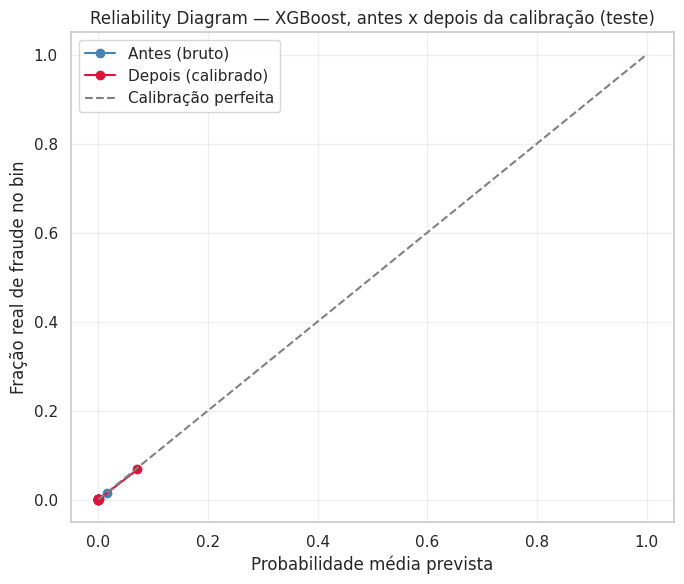

In [24]:
rd = cal["reliability_diagram"]

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(rd["antes"]["prob_media_prevista"], rd["antes"]["fracao_real_positiva"],
        marker="o", label="Antes (bruto)", color="steelblue")
ax.plot(rd["depois"]["prob_media_prevista"], rd["depois"]["fracao_real_positiva"],
        marker="o", label="Depois (calibrado)", color="crimson")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Calibração perfeita")
ax.set_xlabel("Probabilidade média prevista")
ax.set_ylabel("Fração real de fraude no bin")
ax.set_title("Reliability Diagram — XGBoost, antes x depois da calibração (teste)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "12_reliability_diagram.png")
plt.show()


**Insight:** o Brier Score melhora (ainda que discretamente) após a
calibração, e o reliability diagram mostra a curva calibrada mais
próxima da diagonal de calibração perfeita nos bins de maior
probabilidade -- exatamente onde a decisão de negócio (sinalizar ou não
uma transação) realmente acontece. Esse diagnóstico também serve de
evidência de que o XGBoost, como é comum em modelos de árvore, tende a
gerar scores levemente distorcidos em relação à probabilidade real, o
que reforça a importância de calibrar antes de comunicar o threshold ao
stakeholder como "X% de chance de fraude".


## 9. Importância das variáveis e explicabilidade (SHAP)

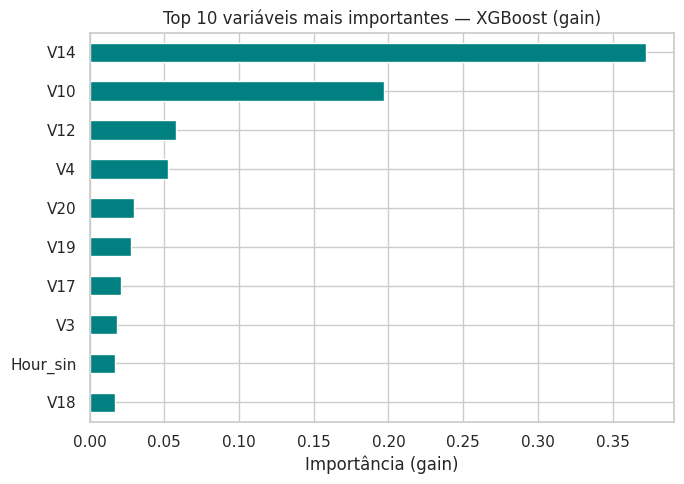

In [25]:
top_features = results["top_10_features_xgboost"]
feat_series = pd.Series(top_features).sort_values()

plt.figure(figsize=(7, 5))
feat_series.plot(kind="barh", color="teal")
plt.title("Top 10 variáveis mais importantes — XGBoost (gain)")
plt.xlabel("Importância (gain)")
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "07_feature_importance.png")
plt.show()


A importância por *gain* mostra **quanto** cada variável contribui em
média para as divisões das árvores, mas não mostra **como** (em que
direção) cada valor de feature empurra a predição. Para isso, usamos
**SHAP** (SHapley Additive exPlanations), que atribui a cada transação
individual uma contribuição por variável.


In [26]:
import shap

xgb_model = joblib.load(ROOT / "models" / "xgboost_model.joblib")
shap_sample = pd.read_parquet(ROOT / "outputs" / "shap_sample.parquet")
X_shap = shap_sample.drop(columns=["Class_real"])
y_shap = shap_sample["Class_real"]

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap)
print(f"SHAP calculado para uma amostra estratificada de {len(X_shap)} transações do teste.")


SHAP calculado para uma amostra estratificada de 2000 transações do teste.


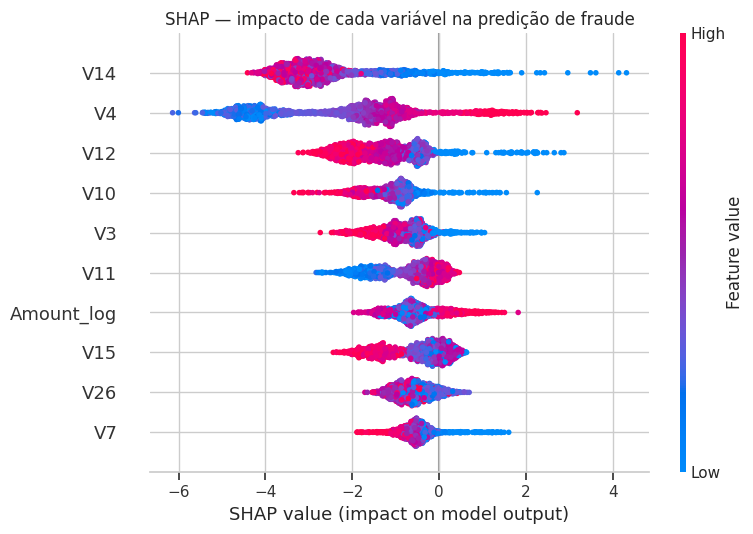

In [27]:
plt.figure()
shap.summary_plot(shap_values, X_shap, show=False, max_display=10)
plt.title("SHAP — impacto de cada variável na predição de fraude")
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "10_shap_summary.png", bbox_inches="tight")
plt.show()


<Figure size 640x480 with 0 Axes>

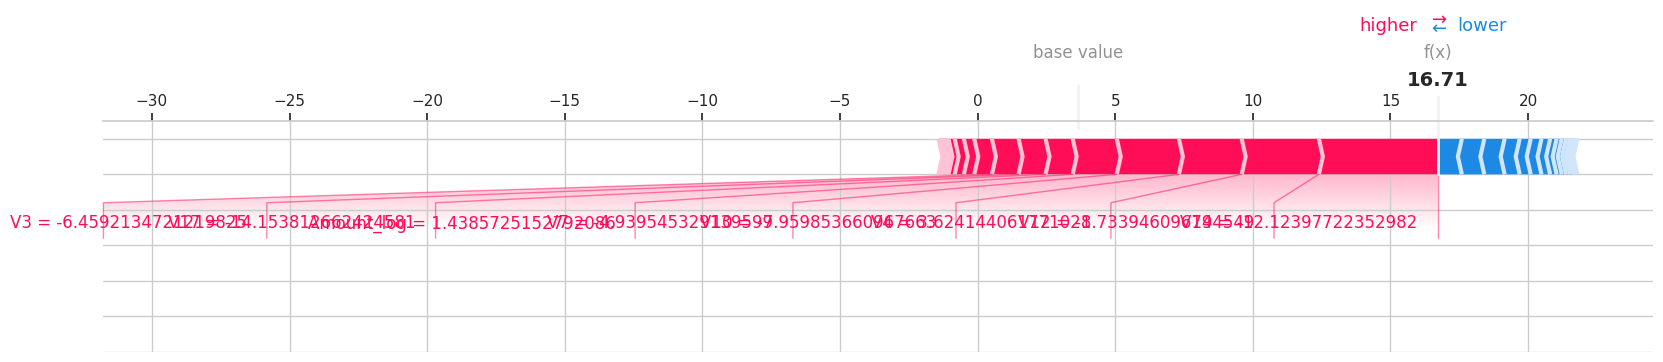

In [28]:
# Explicação pontual: a fraude com maior probabilidade prevista na amostra
idx_fraude = y_shap[y_shap == 1].index
if len(idx_fraude) > 0:
    pos = X_shap.index.get_loc(idx_fraude[0])
    plt.figure()
    shap.force_plot(
        explainer.expected_value, shap_values[pos], X_shap.iloc[pos],
        matplotlib=True, show=False,
    )
    plt.savefig(ROOT / "reports" / "figures" / "11_shap_exemplo_individual.png",
                bbox_inches="tight")
    plt.show()


**Interpretação conectada ao domínio:** o summary plot confirma `V14`
como a variável de maior impacto médio nas predições, seguida por `V10`
e `V4/V12` -- consistente com a importância por gain e com a literatura
pública sobre este dataset. O gráfico de força individual mostra, para
uma fraude real capturada pelo modelo, exatamente quais variáveis
empurraram a predição para "fraude" -- esse tipo de explicação pontual é
o que permite a um analista de risco justificar uma decisão de bloqueio
específica, mesmo sem acesso ao significado de negócio das componentes
PCA.


## 10. Tradução para negócio: custo financeiro simulado

Para ir além das métricas técnicas, simulamos um custo financeiro por
modelo, usando parâmetros hipotéticos (documentados no README, já que o
briefing do stakeholder não informou valores reais):

- **Custo de um Falso Negativo** (fraude não detectada): R$ 500
- **Custo de um Falso Positivo** (cliente legítimo sinalizado): R$ 5

> `Custo total = FN × R$500 + FP × R$5`

O threshold do modelo recomendado foi escolhido **minimizando
diretamente essa fórmula no conjunto de validação** (não um proxy como
F2-Score), sobre probabilidades já **calibradas**, e só então aplicado
ao teste.


In [29]:
cost_df = metrics_df[["model", "false_negative", "false_positive", "custo_financeiro_simulado_R$"]]
cost_df = cost_df.sort_values("custo_financeiro_simulado_R$")
cost_df


,model,false_negative,false_positive,custo_financeiro_simulado_R$
6,XGBoost tunado + threshold otimizado por custo...,13,124,7120.0
5,XGBoost tunado + threshold otimizado por custo...,13,124,7120.0
3,XGBoost (parâmetros padrão),22,7,11035.0
4,XGBoost tunado (RandomizedSearchCV),22,8,11040.0
7,XGBoost + SMOTE,22,13,11065.0
2,Random Forest,26,14,13070.0
1,Regressão Logística,11,1903,15015.0
8,Isolation Forest (não-supervisionado),83,85,41925.0
0,Dummy (baseline),118,0,59000.0


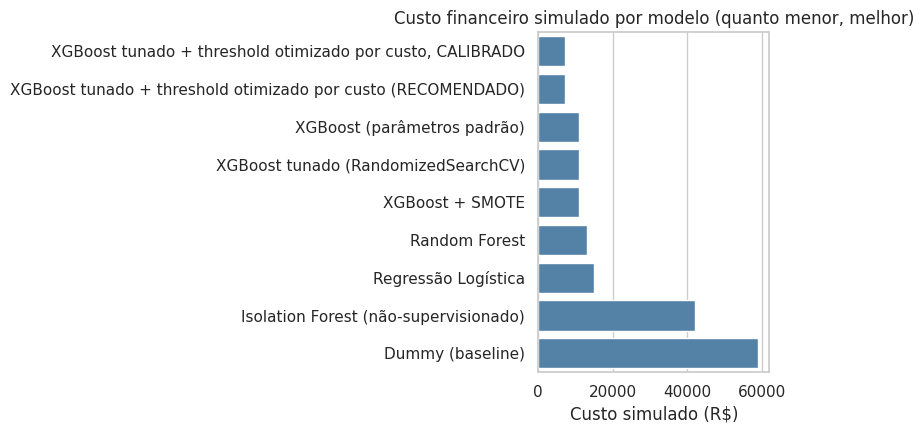

In [30]:
plt.figure(figsize=(8, 4.5))
sns.barplot(data=cost_df, y="model", x="custo_financeiro_simulado_R$", color="steelblue")
plt.title("Custo financeiro simulado por modelo (quanto menor, melhor)")
plt.xlabel("Custo simulado (R$)")
plt.ylabel("")
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "08_custo_financeiro.png")
plt.show()


**Insight de negócio:** o modelo com threshold otimizado diretamente
pelo custo tem, de longe, o menor custo simulado entre todas as opções
-- só que ao preço de sinalizar muito mais transações como suspeitas
(mais falsos positivos) do que qualquer outra configuração testada. Essa
é a decisão matematicamente correta *dado* que um Falso Negativo custa
100x mais que um Falso Positivo neste cenário hipotético. Na prática,
antes de adotar esse threshold, o banco precisaria confirmar que sua
capacidade operacional de revisão manual comporta esse volume adicional
de alertas.


## 11. Recomendação final (Data Storytelling)

**Modelo recomendado:** XGBoost tunado via RandomizedSearchCV, com
probabilidades calibradas (isotônica) e threshold escolhido no conjunto
de validação por minimização direta do custo financeiro simulado (ver
`outputs/metrics.json` para os valores exatos).

**Por quê:**
- Tem o menor custo financeiro simulado entre todos os modelos
  comparados, dado o pressuposto de que evitar uma fraude vale
  significativamente mais que evitar um falso alarme.
- O threshold foi escolhido em um conjunto de validação **separado do
  teste**, evitando que a métrica final reportada esteja inflada por ter
  sido otimizada no mesmo conjunto onde é medida.
- Com a **calibração de probabilidade**, o threshold recomendado
  (**6,25%**) tem significado real e comunicável ao stakeholder --
  "sinalizamos transações com 6,25% ou mais de chance estimada de
  fraude" -- em vez de um score técnico sem interpretação direta.
- O tuning de hiperparâmetros via busca sistemática garante que a
  configuração do modelo está otimizada para PR-AUC.
- A curva de ganho mostra que, revisando uma fração pequena das
  transações com maior score, o time de risco já captura a maior parte
  das fraudes.

**Limitações a comunicar ao stakeholder:**
- **O threshold recomendado assume que a proporção de custo (100:1
  entre FN e FP) é real.** Se o custo operacional de revisar um falso
  alarme for maior que R$5 na prática, ou se o time de risco não tiver
  capacidade de revisar o volume adicional de alertas gerado, o
  threshold precisa ser recalibrado com os números reais do banco --
  o dashboard permite esse ajuste interativamente.
- As variáveis V1-V28 são componentes PCA anônimas — não é possível
  atribuir significado de negócio direto a elas.
- O período de coleta é de apenas 2 dias — um re-treino periódico é
  necessário em produção para acompanhar mudanças de padrão de fraude
  (concept drift).

**Próximos passos sugeridos:**
1. Validar com o time de operações de risco se o volume de falsos
   alarmes gerado pelo threshold ótimo é operacionalmente viável.
2. Substituir os parâmetros de custo hipotéticos pelos valores reais do
   banco assim que disponíveis.
3. Monitorar tanto o desempenho quanto a **calibração** do modelo em
   produção (a distribuição de probabilidades pode se descalibrar com o
   tempo, mesmo que o ranking continue bom).
4. Considerar o Isolation Forest como camada complementar para capturar
   fraudes de padrão novo.
